# Stochastic gradient descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Consider applying stochastic gradient descent to minimize
$$
\min_{x\in\mathbb{R}} f_1(x) + f_2(x)
$$
where $f_1(x) = (x-1)^2$ and $f_2(x) = (x+1)^2$.

In [2]:
def f(x,i):
    if i==1:
        return (x-1)**2
    else:
        return (x+1)**2
    
def df(x,i):
    if i==1:
        return 2*(x-1)
    else:
        return 2*(x+1)
    
def F(x):
    return f(x,1)+f(x,2)

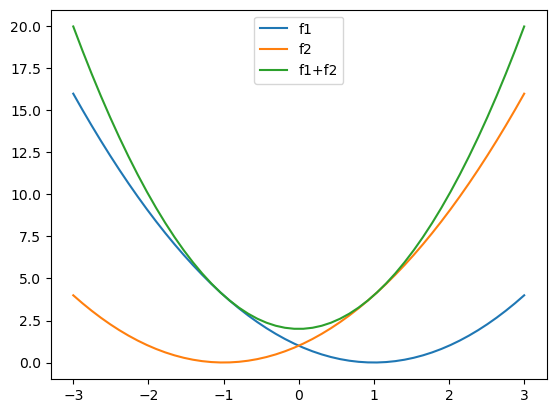

In [3]:
x = np.linspace(-3,3)
plt.plot(x, f(x,1), label='f1')
plt.plot(x, f(x,2), label='f2')
plt.plot(x, F(x), label='f1+f2')
plt.legend()

Each iteration of SGD reads
$$
w_{k+1} = w_k - \tau_k \nabla f_{i_k}(x_k)
$$
where $i_k\in \{1,2\}$ drawn uniformly.

In [4]:
niter = 10000
runs = 20
w_arr = np.zeros((niter,runs))


for r in range(runs): #run SGD multiple times
    w = .1 #initialisation
    for k in range(niter):
        tau = 1/(1+.1*k)
        i = np.random.randint(2) #choose an index at random from {0,1}
        w = w - tau*df(w,i)
        w_arr[k,r] = w

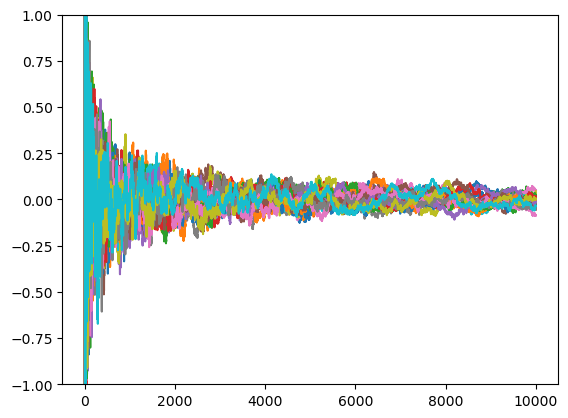

In [5]:
plt.plot(w_arr)
plt.ylim([-1,1])
plt.show()

Load a dataset from sklearn. This breast cancer dataset is for binary classification (whether a cancer is benign or malignant). The label $y$ takes value -1 or 1.

In [6]:
import sklearn.datasets as dataset
X,y = dataset.load_breast_cancer(return_X_y=True)

# normalize the dataset
X = X-X.mean(axis=0)
X = X/X.std(axis=0)

# shift y to take value in -1,1
y = y*2-1

n,m = X.shape



We first perform gradient descent, by minimzing the following function
$$
\min_w E(w) = \frac{1}{n} \sum_{i=1}^n L(x_i^\top w, y_i)
$$
where $L$ is the logistic loss 
$$
L(s,y) = \log(1+\exp(-sy)).
$$

In [7]:
def L(s,y):  return 1/n * np.sum( np.log( 1 + np.exp(-s*y) ) )
def E(w,X,y): return L(X.dot(w),y)
def theta(v): return 1 / (1+np.exp(-v))
def nablaL(s,y): return - 1/n * y * theta(-s * y)
def nablaE(w,X,y): return X.transpose().dot( nablaL(X.dot(w),y) ) 


In [9]:
niter = 20000
w = np.zeros((m,))
funcvals = []
tau = .2
for i in range(niter):
    w = w - tau*nablaE(w,X,y)
    funcvals.append(E(w,X,y))
    
minval = np.min(funcvals)

Implement SGD and plot the convergence behaviour over several runs.

In [10]:


def theta(v): return 1 / (1+np.exp(-v))
def nablaEi(w,i): return -y[i] * X[i,:] * theta( -y[i] * (X[i,:].dot(w)) ) 

runs = 10
funcvals_sgd = np.zeros((niter,runs))
for r in range(runs):
    ws = np.zeros((m,))
    for k in range(niter):
        funcvals_sgd[k,r] = (E(ws,X,y))
        tau = 1/(1+k/100)
        i = np.random.randint(n)
        ws = ws - tau*nablaEi(ws,i)
    
    


(0.0, 1.0)

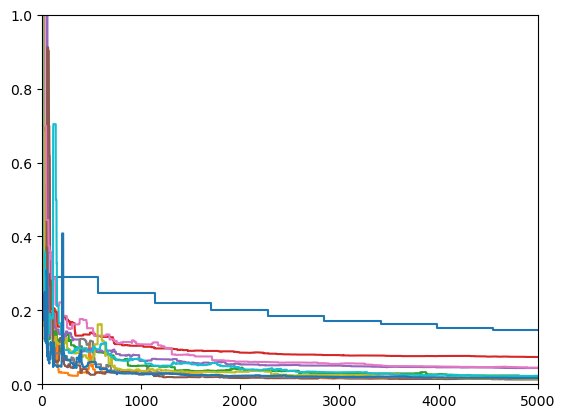

In [30]:
minval = np.min(funcvals)
plt.step(np.arange(0,niter*n,n),funcvals-minval)

plt.plot(np.arange(0,niter),funcvals_sgd-minval)

plt.xlim([0,niter//4])
plt.ylim([0,1])


It is known that SGD converges with rate
$$
\mathbb{E}(F(w_k) - F(w_*)) = \mathcal{O}(k^{-\frac12})
$$
Let us verify this numerically

/var/folders/66/nkvnf29126df246qsqb2j5y80000gq/T/ipykernel_1236/2590296499.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.loglog(np.arange(0,niter),1/np.sqrt(np.arange(0,niter)), 'k--')


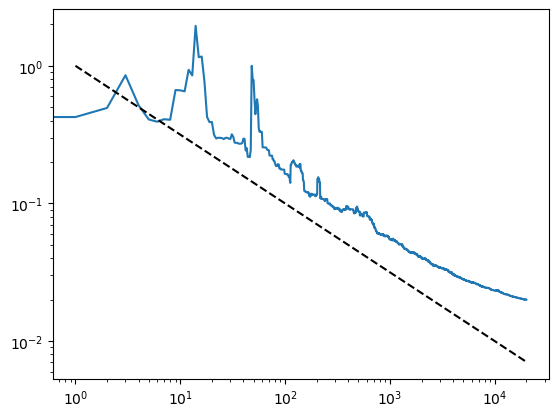

In [24]:

plt.loglog(np.arange(0,niter),np.mean(funcvals_sgd,1)-minval)
plt.loglog(np.arange(0,niter),1/np.sqrt(np.arange(0,niter)), 'k--')